<span style="color:Yellow ; font-size: 55px;">AmirhoseinSabahi 810101556</span>

<span style="color: #177cff ; font-size: 40px;">Introduction to PyTorch</span>

We're gonna need some packages for this tutorial:

In [1]:
## Standard libraries
import os
import math
import numpy as np
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

/tmp/ipython-input-47578708.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


<span style="color: gold; font-size: 30px;">Part 0: The Basics of PyTorch</span>

So, let's start with importing PyTorch. The package is called `torch`, based on its original framework [Torch](http://torch.ch/). As a first step, we can check its version:

In [2]:
import torch
print("Using torch", torch.__version__)

Using torch 2.9.0+cpu


As in every machine learning framework, PyTorch provides functions that are stochastic like generating random numbers. However, a very good practice is to setup your code to be reproducible with the exact same random numbers. This is why we set a seed below.

In [3]:
torch.manual_seed(42) # Setting the seed

<span style="color: red; font-size: 25px;">Tensors</span>

Tensors are the PyTorch equivalent to Numpy arrays, with the addition to also have support for GPU acceleration (more on that later).
The name "tensor" is a generalization of concepts you already know. For instance, a vector is a 1-D tensor, and a matrix a 2-D tensor. When working with neural networks, we will use tensors of various shapes and number of dimensions.

Most common functions you know from numpy can be used on tensors as well. Actually, since numpy arrays are so similar to tensors, we can convert most tensors to numpy arrays (and back) but we don't need it too often.

#### Initialization

Let's first start by looking at different ways of creating a tensor. There are many possible options, the simplest one is to call `torch.Tensor` passing the desired shape as input argument:

In [4]:
x = torch.Tensor(2, 3, 4)
print(x)

tensor([[[-7.9364e+19,  4.3756e-41, -7.9364e+19,  4.3756e-41],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [-2.1710e-32,  4.3756e-41, -2.1804e-32,  4.3756e-41]],

        [[-2.1965e-32,  4.3756e-41, -2.1836e-32,  4.3756e-41],
         [-2.1710e-32,  4.3756e-41, -2.1710e-32,  4.3756e-41],
         [-2.1775e-32,  4.3756e-41, -2.1775e-32,  4.3756e-41]]])


The function `torch.Tensor` allocates memory for the desired tensor, but reuses any values that have already been in the memory. To directly assign values to the tensor during initialization, there are many alternatives including:

* `torch.zeros`: Creates a tensor filled with zeros
* `torch.rand`: Creates a tensor with random values uniformly sampled between 0 and 1
* `torch.arange`: Creates a tensor containing the values $N,N+1,N+2,...,M$
* `torch.Tensor` (input list): Creates a tensor from the list elements you provide

In [5]:
# Create a tensor from a (nested) list
x = torch.Tensor([[1, 2], [3, 4]])
print(x)

tensor([[1., 2.],
        [3., 4.]])


In [6]:
# Create a tensor with random values between 0 and 1 with the shape [2, 3, 4]
x = torch.rand(2, 3, 4)
print(x)

tensor([[[0.8823, 0.9150, 0.3829, 0.9593],
         [0.3904, 0.6009, 0.2566, 0.7936],
         [0.9408, 0.1332, 0.9346, 0.5936]],

        [[0.8694, 0.5677, 0.7411, 0.4294],
         [0.8854, 0.5739, 0.2666, 0.6274],
         [0.2696, 0.4414, 0.2969, 0.8317]]])


You can obtain the shape of a tensor in the same way as in numpy (`x.shape`), or using the `.size` method:

In [7]:
shape = x.shape
print("Shape:", x.shape)

size = x.size()
print("Size:", size)

dim1, dim2, dim3 = x.size()
print("Size:", dim1, dim2, dim3)

Shape: torch.Size([2, 3, 4])
Size: torch.Size([2, 3, 4])
Size: 2 3 4


<span style="color: red; font-size: 25px;">Operations</span>

Most operations that exist in numpy, also exist in PyTorch. A full list of operations can be found in the [PyTorch documentation](https://pytorch.org/docs/stable/tensors.html#), but we will review the most important ones here.

The simplest operation is to add two tensors:

In [8]:
x1 = torch.rand(2, 3)
x2 = torch.rand(2, 3)
y = x1 + x2

print("X1", x1)
print("X2", x2)
print("Y", y)

X1 tensor([[0.1053, 0.2695, 0.3588],
        [0.1994, 0.5472, 0.0062]])
X2 tensor([[0.9516, 0.0753, 0.8860],
        [0.5832, 0.3376, 0.8090]])
Y tensor([[1.0569, 0.3448, 1.2448],
        [0.7826, 0.8848, 0.8151]])


Another common operation aims at changing the shape of a tensor. A tensor of size (2,3) can be re-organized to any other shape with the same number of elements (e.g. a tensor of size (6), or (3,2), ...). In PyTorch, this operation is called `view`:

In [9]:
x = torch.arange(6)
print("X", x)

X tensor([0, 1, 2, 3, 4, 5])


In [10]:
x = x.view(2, 3)
print("X", x)

X tensor([[0, 1, 2],
        [3, 4, 5]])


In [11]:
x = x.permute(1, 0) # Swapping dimension 0 and 1
print("X", x)

X tensor([[0, 3],
        [1, 4],
        [2, 5]])


Other commonly used operations include matrix multiplications, which are essential for neural networks. Quite often, we have an input vector $\mathbf{x}$, which is transformed using a learned weight matrix $\mathbf{W}$. There are multiple ways and functions to perform matrix multiplication, some of which we list below:

* `torch.matmul`: Performs the matrix product over two tensors, where the specific behavior depends on the dimensions. If both inputs are matrices (2-dimensional tensors), it performs the standard matrix product. For higher dimensional inputs, the function supports broadcasting (for details see the [documentation](https://pytorch.org/docs/stable/generated/torch.matmul.html?highlight=matmul#torch.matmul)). Can also be written as `a @ b`, similar to numpy.
* `torch.mm`: Performs the matrix product over two matrices, but doesn't support broadcasting (see [documentation](https://pytorch.org/docs/stable/generated/torch.mm.html?highlight=torch%20mm#torch.mm))

Usually, we use `torch.matmul`. We can try a matrix multiplication with `torch.matmul` below.

In [12]:
x = torch.arange(6)
x = x.view(2, 3)
print("X", x)

X tensor([[0, 1, 2],
        [3, 4, 5]])


In [13]:
W = torch.arange(9).view(3, 3) # We can also stack multiple operations in a single line
print("W", W)

W tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


In [14]:
h = torch.matmul(x, W) # Verify the result by calculating it by hand too!
print("h", h)

h tensor([[15, 18, 21],
        [42, 54, 66]])


<span style="color: red; font-size: 25px;">Indexing</span>

We often have the situation where we need to select a part of a tensor. Indexing works just like in numpy, so let's try it:

In [15]:
x = torch.arange(12).view(3, 4)
print("X", x)

X tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [16]:
print(x[:, 1])   # Second column

tensor([1, 5, 9])


In [17]:
print(x[0])      # First row

tensor([0, 1, 2, 3])


In [18]:
print(x[:2, -1]) # First two rows, last column

tensor([3, 7])


In [19]:
print(x[1:3, :]) # Middle two rows

tensor([[ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


<span style="color: red; font-size: 25px;">Tensors Aren’t Just Images and Numbers: Handling Text Inputs</span>

In deep learning, every type of input images, audio, or text, must eventually be represented as a tensor.
For NLP tasks, sentences are typically tokenized into integer IDs and then mapped into vector representations using an Embedding layer.
The short examples below illustrate how a piece of text becomes a tensor that can be processed by any PyTorch model.

In [20]:
vocab = {"i":1, "love":2, "UT":3}
sentence = ["i", "love", "UT"]
ids = torch.tensor([vocab[w] for w in sentence])
ids

tensor([1, 2, 3])

In [21]:
embedding = torch.nn.Embedding(num_embeddings=10, embedding_dim=8)
embedded = embedding(ids)
embedded.shape

torch.Size([3, 8])

###
<span style="color: red; font-size: 25px;">Dynamic Computation Graph and Backpropagation (Just for more information)</span>


One of the main reasons for using PyTorch in Deep Learning projects is that we can automatically get **gradients/derivatives** of functions that we define. We will mainly use PyTorch for implementing neural networks, and they are just fancy functions. If we use weight matrices in our function that we want to learn, then those are called the **parameters** or simply the **weights**.

If our neural network would output a single scalar value, we would talk about taking the **derivative**, but you will see that quite often we will have **multiple** output variables ("values"); in that case we talk about **gradients**. It's a more general term.

So, to recap: the only thing we have to do is to compute the **output**, and then we can ask PyTorch to automatically get the **gradients**. We are automatically creating a **computational graph**.

In [22]:
x = torch.ones((3,))
print(x.requires_grad)

False


We can change this for an existing tensor using the function `requires_grad_()` (underscore indicating that this is a in-place operation). Alternatively, when creating a tensor, you can pass the argument `requires_grad=True` to most initializers we have seen above.

In [23]:
x.requires_grad_(True)
print(x.requires_grad)

True


In order to get familiar with the concept of a computation graph, we will create one for the following function:

$$y = \frac{1}{\ell(x)}\sum_i \left[(x_i + 2)^2 + 3\right],$$

where we use $\ell(x)$ to denote the number of elements in $x$. In other words, we are taking a mean here over the operation within the sum. You could imagine that $x$ are our parameters, and we want to optimize (either maximize or minimize) the output $y$. For this, we want to obtain the gradients $\partial y / \partial \mathbf{x}$. For our example, we'll use $\mathbf{x}=[0,1,2]$ as our input.

In [24]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True) # Only float tensors can have gradients
print("X", x)

X tensor([0., 1., 2.], requires_grad=True)


Now let's build the computation graph step by step. You can combine multiple operations in a single line, but we will separate them here to get a better understanding of how each operation is added to the computation graph.

In [25]:
a = x + 2
b = a ** 2
c = b + 3
y = c.mean()
print("Y", y)

Y tensor(12.6667, grad_fn=<MeanBackward0>)


Using the statements above, we have created a computation graph that looks similar to the figure below:

<center style="width: 100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/pytorch_computation_graph.svg?raw=1" width="200px"></center>

We calculate $a$ based on the inputs $x$ and the constant $2$, $b$ is $a$ squared, and so on. The visualization is an abstraction of the dependencies between inputs and outputs of the operations we have applied.
Each node of the computation graph has automatically defined a function for calculating the gradients with respect to its inputs, `grad_fn`. You can see this when we printed the output tensor $y$. This is why the computation graph is usually visualized in the reverse direction (arrows point from the result to the inputs). We can perform backpropagation on the computation graph by calling the function `backward()` on the last output, which effectively calculates the gradients for each tensor that has the property `requires_grad=True`:

In [26]:
y.backward()

`x.grad` will now contain the gradient $\partial y/ \partial \mathcal{x}$, and this gradient indicates how a change in $\mathbf{x}$ will affect output $y$ given the current input $\mathbf{x}=[0,1,2]$:

In [27]:
print(x.grad)

tensor([1.3333, 2.0000, 2.6667])


We can also verify these gradients by hand. We will calculate the gradients using the chain rule, in the same way as PyTorch did it:

$$\frac{\partial y}{\partial x_i} = \frac{\partial y}{\partial c_i}\frac{\partial c_i}{\partial b_i}\frac{\partial b_i}{\partial a_i}\frac{\partial a_i}{\partial x_i}$$

Note that we have simplified this equation to index notation, and by using the fact that all operation besides the mean do not combine the elements in the tensor. The partial derivatives are:

$$
\frac{\partial a_i}{\partial x_i} = 1,\hspace{1cm}
\frac{\partial b_i}{\partial a_i} = 2\cdot a_i\hspace{1cm}
\frac{\partial c_i}{\partial b_i} = 1\hspace{1cm}
\frac{\partial y}{\partial c_i} = \frac{1}{3}
$$

Hence, with the input being $\mathbf{x}=[0,1,2]$, our gradients are $\partial y/\partial \mathbf{x}=[4/3,2,8/3]$. The previous code cell should have printed the same result.

<span style="color: red; font-size: 25px;">GPU Support</span>

A crucial feature of PyTorch is the support of GPUs, short for Graphics Processing Unit. A GPU can perform many thousands of small operations in parallel, making it very well suitable for performing large matrix operations in neural networks. When comparing GPUs to CPUs, we can list the following main differences (credit: [Kevin Krewell, 2009](https://blogs.nvidia.com/blog/2009/12/16/whats-the-difference-between-a-cpu-and-a-gpu/))

<center style="width: 100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/comparison_CPU_GPU.png?raw=1" width="700px"></center>

CPUs and GPUs have both different advantages and disadvantages, which is why many computers contain both components and use them for different tasks. In case you are not familiar with GPUs, you can read up more details in this [NVIDIA blog post](https://blogs.nvidia.com/blog/2009/12/16/whats-the-difference-between-a-cpu-and-a-gpu/) or [here](https://www.intel.com/content/www/us/en/products/docs/processors/what-is-a-gpu.html).

GPUs can accelerate the training of your network up to a factor of $100$ which is essential for large neural networks. PyTorch implements a lot of functionality for supporting GPUs (mostly those of NVIDIA due to the libraries [CUDA](https://developer.nvidia.com/cuda-zone) and [cuDNN](https://developer.nvidia.com/cudnn)). First, let's check whether you have a GPU available:

By default, all tensors you create are stored on the CPU. We can push a tensor to the GPU by using the function `.to(...)`, or `.cuda()`. However, it is often a good practice to define a `device` object in your code which points to the GPU if you have one, and otherwise to the CPU. Then, you can write your code with respect to this device object, and it allows you to run the same code on both a CPU-only system, and one with a GPU. Let's try it below. We can specify the device as follows:

In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cpu


Now let's create a tensor and push it to the device:

In [29]:
x = torch.zeros(2, 3)
x = x.to(device)
print("X", x)

X tensor([[0., 0., 0.],
        [0., 0., 0.]])


In case you have a GPU, you should now see the attribute `device='cuda:0'` being printed next to your tensor. The zero next to cuda indicates that this is the zero-th GPU device on your computer. PyTorch also supports multi-GPU systems, but this you will only need once you have very big networks to train (if interested, see the [PyTorch documentation](https://pytorch.org/docs/stable/distributed.html#distributed-basics)). We can also compare the runtime of a large matrix multiplication on the CPU with a operation on the GPU:

In [30]:
x = torch.randn(5000, 5000)

## CPU version
start_time = time.time()
_ = torch.matmul(x, x)
end_time = time.time()
print(f"CPU time: {(end_time - start_time):6.5f}s")



CPU time: 3.88442s


<span style="color: gold; font-size: 30px;">Part 1: Learning By Example</span>

In PyTorch, there is a package called `torch.nn` that makes building neural networks more convenient.

We will introduce the libraries and all additional parts you might need to train a neural network in PyTorch, using a simple example classifier on a simple yet well known example: XOR. Given two binary inputs $x_1$ and $x_2$, the label to predict is $1$ if either $x_1$ or $x_2$ is $1$ while the other is $0$, or the label is $0$ in all other cases. The example became famous by the fact that a single neuron, i.e. a linear classifier, cannot learn this simple function.
Hence, we will learn how to build a small neural network that can learn this function.
To make it a little bit more interesting, we move the XOR into continuous space and introduce some gaussian noise on the binary inputs. Our desired separation of an XOR dataset could look as follows:

<center style="width: 100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/continuous_xor.svg?raw=1" width="350px"></center>

<span style="color: red; font-size: 25px;">The Model</span>

The package `torch.nn` defines a series of useful classes like linear networks layers, activation functions, loss functions etc. A full list can be found [here](https://pytorch.org/docs/stable/nn.html). In case you need a certain network layer, check the documentation of the package first before writing the layer yourself as the package likely contains the code for it already. We import it below:

In [31]:
import torch.nn as nn

Additionally to `torch.nn`, there is also `torch.nn.functional`. It contains functions that are used in network layers. This is in contrast to `torch.nn` which defines them as `nn.Modules` (more on it below), and `torch.nn` actually uses a lot of functionalities from `torch.nn.functional`. Hence, the functional package is useful in many situations, and so we import it as well here.

In [32]:
import torch.nn.functional as F

#### nn.Module

In PyTorch, a neural network is built up out of modules. Modules can contain other modules, and a neural network is considered to be a module itself as well. The basic template of a module is as follows:

In [33]:
class MyModule(nn.Module):

    def __init__(self):
        super().__init__()
        # Some init for my module

    def forward(self, x):
        # Function for performing the calculation of the module.
        pass

The forward function is where the computation of the module is taken place, and is executed when you call the module (`nn = MyModule(); nn(x)`). In the init function, we usually create the parameters of the module, using `nn.Parameter`, or defining other modules that are used in the forward function. The backward calculation is done automatically, but could be overwritten as well if wanted.

#### Simple classifier
We can now make use of the pre-defined modules in the `torch.nn` package, and define our own small neural network. We will use a minimal network with a input layer, one hidden layer with tanh as activation function, and a output layer. In other words, our networks should look something like this:

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/small_neural_network.svg?raw=1" width="300px"></center>

The input neurons are shown in blue, which represent the coordinates $x_1$ and $x_2$ of a data point. The hidden neurons including a tanh activation are shown in white, and the output neuron in red.
In PyTorch, we can define this as follows:

In [34]:
class SimpleClassifier(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Initialize the modules we need to build the network
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

For the examples in this notebook, we will use a tiny neural network with two input neurons and four hidden neurons. As we perform binary classification, we will use a single output neuron. Note that we do not apply a sigmoid on the output yet. This is because other functions, especially the loss, are more efficient and precise to calculate on the original outputs instead of the sigmoid output. We will discuss the detailed reason later.

In [35]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
# Printing a module shows all its submodules
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


Printing the model lists all submodules it contains. The parameters of a module can be obtained by using its `parameters()` functions, or `named_parameters()` to get a name to each parameter object. For our small neural network, we have the following parameters:

In [36]:
for name, param in model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}")

Parameter linear1.weight, shape torch.Size([4, 2])
Parameter linear1.bias, shape torch.Size([4])
Parameter linear2.weight, shape torch.Size([1, 4])
Parameter linear2.bias, shape torch.Size([1])


Each linear layer has a weight matrix of the shape `[output, input]`, and a bias of the shape `[output]`. The tanh activation function does not have any parameters. Note that parameters are only registered for `nn.Module` objects that are direct object attributes, i.e. `self.a = ...`. If you define a list of modules, the parameters of those are not registered for the outer module and can cause some issues when you try to optimize your module. There are alternatives, like `nn.ModuleList`, `nn.ModuleDict` and `nn.Sequential`, that allow you to have different data structures of modules. We will use them in a few later tutorials and explain them there.

<span style="color: red; font-size: 25px;">The Data</span>


PyTorch also provides a few functionalities to load the training and test data efficiently, summarized in the package `torch.utils.data`.

In [37]:
import torch.utils.data as data

The data package defines two classes which are the standard interface for handling data in PyTorch: `data.Dataset`, and `data.DataLoader`. The dataset class provides an uniform interface to access the training/test data, while the data loader makes sure to efficiently load and stack the data points from the dataset into batches during training.

#### The dataset class

The dataset class summarizes the basic functionality of a dataset in a natural way. To define a dataset in PyTorch, we simply specify two functions: `__getitem__`, and `__len__`. The get-item function has to return the $i$-th data point in the dataset, while the len function returns the size of the dataset. For the XOR dataset, we can define the dataset class as follows:

In [38]:
class XORDataset(data.Dataset):

    def __init__(self, size, std=0.1):
        """
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Each data point in the XOR dataset has two variables, x and y, that can be either 0 or 1
        # The label is their XOR combination, i.e. 1 if only x or only y is 1 while the other is 0.
        # If x=y, the label is 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # To make it slightly more challenging, we add a bit of gaussian noise to the data points.
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

Let's try to create such a dataset and inspect it:

In [39]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

Size of dataset: 200
Data point 0: (tensor([-0.0217, -0.1180]), tensor(0))


To better relate to the dataset, we visualize the samples below.

In [40]:
def visualize_samples(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4,4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

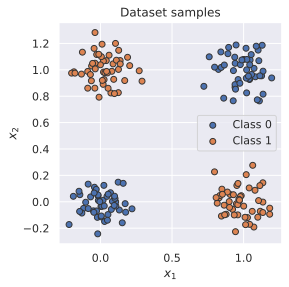

In [41]:
visualize_samples(dataset.data, dataset.label)
plt.show()

#### The data loader class

The class `torch.utils.data.DataLoader` represents a Python iterable over a dataset with support for automatic batching, multi-process data loading and many more features. The data loader communicates with the dataset using the function `__getitem__`, and stacks its outputs as tensors over the first dimension to form a batch.
In contrast to the dataset class, we usually don't have to define our own data loader class, but can just create an object of it with the dataset as input. Additionally, we can configure our data loader with the following input arguments (only a selection, see full list [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)):

* `batch_size`: Number of samples to stack per batch
* `shuffle`: If True, the data is returned in a random order. This is important during training for introducing stochasticity.
* `num_workers`: Number of subprocesses to use for data loading. The default, 0, means that the data will be loaded in the main process which can slow down training for datasets where loading a data point takes a considerable amount of time (e.g. large images). More workers are recommended for those, but can cause issues on Windows computers. For tiny datasets as ours, 0 workers are usually faster.
* `pin_memory`: If True, the data loader will copy Tensors into CUDA pinned memory before returning them. This can save some time for large data points on GPUs. Usually a good practice to use for a training set, but not necessarily for validation and test to save memory on the GPU.
* `drop_last`: If True, the last batch is dropped in case it is smaller than the specified batch size. This occurs when the dataset size is not a multiple of the batch size. Only potentially helpful during training to keep a consistent batch size.

Let's create a simple data loader below:

In [42]:
data_loader = data.DataLoader(dataset, batch_size=8, shuffle=True)

In [43]:
# next(iter(...)) catches the first batch of the data loader
# If shuffle is True, this will return a different batch every time we run this cell
# For iterating over the whole dataset, we can simple use "for batch in data_loader: ..."
data_inputs, data_labels = next(iter(data_loader))

# The shape of the outputs are [batch_size, d_1,...,d_N] where d_1,...,d_N are the
# dimensions of the data point returned from the dataset class
print("Data inputs", data_inputs.shape, "\n", data_inputs)
print("Data labels", data_labels.shape, "\n", data_labels)

Data inputs torch.Size([8, 2]) 
 tensor([[ 1.1257,  0.9543],
        [ 0.9832,  0.0462],
        [ 1.0004,  1.0789],
        [-0.0889,  0.9878],
        [ 0.9692,  0.0072],
        [ 0.9400,  0.8880],
        [-0.1895,  0.0415],
        [ 0.1050,  1.2001]])
Data labels torch.Size([8]) 
 tensor([0, 1, 0, 1, 1, 0, 0, 1])


<span style="color: red; font-size: 25px;">Optimization</span>

After defining the model and the dataset, it is time to prepare the optimization of the model. During training, we will perform the following steps:

1. Get a batch from the data loader
2. Obtain the predictions from the model for the batch
3. Calculate the loss based on the difference between predictions and labels
4. Backpropagation: calculate the gradients for every parameter with respect to the loss
5. Update the parameters of the model in the direction of the gradients

We have seen how we can do step 1, 2 and 4 in PyTorch. Now, we will look at step 3 and 5.

#### Loss modules

We can calculate the loss for a batch by simply performing a few tensor operations as those are automatically added to the computation graph. For instance, for binary classification, we can use Binary Cross Entropy (BCE) which is defined as follows:

$$\mathcal{L}_{BCE} = -\sum_i \left[ y_i \log x_i + (1 - y_i) \log (1 - x_i) \right]$$

where $y$ are our labels, and $x$ our predictions, both in the range of $[0,1]$. However, PyTorch already provides a list of predefined loss functions which we can use (see [here](https://pytorch.org/docs/stable/nn.html#loss-functions) for a full list). For instance, for BCE, PyTorch has two modules: `nn.BCELoss()`, `nn.BCEWithLogitsLoss()`. While `nn.BCELoss` expects the inputs $x$ to be in the range $[0,1]$, i.e. the output of a sigmoid, `nn.BCEWithLogitsLoss` combines a sigmoid layer and the BCE loss in a single class. This version is numerically more stable than using a plain Sigmoid followed by a BCE loss because of the logarithms applied in the loss function. Hence, it is adviced to use loss functions applied on "logits" where possible (remember to not apply a sigmoid on the output of the model in this case!). For our model defined above, we therefore use the module `nn.BCEWithLogitsLoss`.

In [44]:
loss_module = nn.BCEWithLogitsLoss()

#### Stochastic Gradient Descent

For updating the parameters, PyTorch provides the package `torch.optim` that has most popular optimizers implemented. We will discuss the specific optimizers and their differences later in the course, but will for now use the simplest of them: `torch.optim.SGD`. Stochastic Gradient Descent updates parameters by multiplying the gradients with a small constant, called learning rate, and subtracting those from the parameters (hence minimizing the loss). Therefore, we slowly move towards the direction of minimizing the loss. A good default value of the learning rate for a small network as ours is 0.1.

In [45]:
# Input to the optimizer are the parameters of the model: model.parameters()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

The optimizer provides two useful functions: `optimizer.step()`, and `optimizer.zero_grad()`. The step function updates the parameters based on the gradients as explained above. The function `optimizer.zero_grad()` sets the gradients of all parameters to zero. While this function seems less relevant at first, it is a crucial pre-step before performing backpropagation. If we call the `backward` function on the loss while the parameter gradients are non-zero from the previous batch, the new gradients would actually be added to the previous ones instead of overwriting them. This is done because a parameter might occur multiple times in a computation graph, and we need to sum the gradients in this case instead of replacing them. Hence, remember to call `optimizer.zero_grad()` before calculating the gradients of a batch.

<span style="color: red; font-size: 25px;">Training</span>

Finally, we are ready to train our model. As a first step, we create a slightly larger dataset and specify a data loader with a larger batch size.

In [46]:
train_dataset = XORDataset(size=2500)
train_data_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)

Now, we can write a small training function. Remember our five steps: load a batch, obtain the predictions, calculate the loss, backpropagate, and update. Additionally, we have to push all data and model parameters to the device of our choice (GPU if available). For the tiny neural network we have, communicating the data to the GPU actually takes much more time than we could save from running the operation on CPU. For large networks, the communication time is significantly smaller than the actual runtime making a GPU crucial in these cases. Still, to practice, we will push the data to GPU here.

In [47]:
# Push model to device. Has to be only done once
model.to(device)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)

In addition, we set our model to training mode. This is done by calling `model.train()`. There exist certain modules that need to perform a different forward step during training than during testing (e.g. BatchNorm and Dropout), and we can switch between them using `model.train()` and `model.eval()`.

<span style="color: lightgreen; font-size: 22px;">Your Task: Warmup</span>

In this warmup assignment, you will implement a basic training loop in PyTorch.
The goal is to understand the core steps of training a neural network,
including setting the model to training mode, performing a forward pass,
computing the loss, and updating model parameters using backpropagation.


In [48]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:

            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)

            loss = loss_module(preds, data_labels.float())

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()



In [49]:
train_model(model, optimizer, train_data_loader, loss_module)

  0%|          | 0/100 [00:00<?, ?it/s]

#### Saving a model

After finish training a model, we save the model to disk so that we can load the same weights at a later time. For this, we extract the so-called `state_dict` from the model which contains all learnable parameters. For our simple model, the state dict contains the following entries:

In [50]:
state_dict = model.state_dict()
print(state_dict)

OrderedDict({'linear1.weight': tensor([[-0.1002,  0.8844],
        [-2.2993,  3.1965],
        [-2.2086, -2.1569],
        [-3.4206,  2.6247]]), 'linear1.bias': tensor([-0.3227,  0.8626,  0.3992, -1.0370]), 'linear2.weight': tensor([[-0.8517, -4.2070, -3.2065,  4.5583]]), 'linear2.bias': tensor([1.5826])})


To save the state dictionary, we can use `torch.save`:

In [51]:
# torch.save(object, filename). For the filename, any extension can be used
torch.save(state_dict, "our_model.tar")

To load a model from a state dict, we use the function `torch.load` to load the state dict from the disk, and the module function `load_state_dict` to overwrite our parameters with the new values:

In [52]:
# Load state dict from the disk (make sure it is the same name as above)
state_dict = torch.load("our_model.tar")

# Create a new model and load the state
new_model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
new_model.load_state_dict(state_dict)

# Verify that the parameters are the same
print("Original model\n", model.state_dict())
print("\nLoaded model\n", new_model.state_dict())

Original model
 OrderedDict({'linear1.weight': tensor([[-0.1002,  0.8844],
        [-2.2993,  3.1965],
        [-2.2086, -2.1569],
        [-3.4206,  2.6247]]), 'linear1.bias': tensor([-0.3227,  0.8626,  0.3992, -1.0370]), 'linear2.weight': tensor([[-0.8517, -4.2070, -3.2065,  4.5583]]), 'linear2.bias': tensor([1.5826])})

Loaded model
 OrderedDict({'linear1.weight': tensor([[-0.1002,  0.8844],
        [-2.2993,  3.1965],
        [-2.2086, -2.1569],
        [-3.4206,  2.6247]]), 'linear1.bias': tensor([-0.3227,  0.8626,  0.3992, -1.0370]), 'linear2.weight': tensor([[-0.8517, -4.2070, -3.2065,  4.5583]]), 'linear2.bias': tensor([1.5826])})


A detailed tutorial on saving and loading models in PyTorch can be found [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

<span style="color: red; font-size: 25px;">Evaluation and Visualization</span>

Once we have trained a model, it is time to evaluate it on a held-out test set. As our dataset consist of randomly generated data points, we need to first create a test set with a corresponding data loader.

In [53]:
test_dataset = XORDataset(size=500)
# drop_last -> Don't drop the last batch although it is smaller than 128
test_data_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)

As metric, we will use accuracy which is calculated as follows:

$$acc = \frac{\#\text{correct predictions}}{\#\text{all predictions}} = \frac{TP+TN}{TP+TN+FP+FN}$$

where TP are the true positives, TN true negatives, FP false positives, and FN the fale negatives.

When evaluating the model, we don't need to keep track of the computation graph as we don't intend to calculate the gradients. This reduces the required memory and speed up the model. In PyTorch, we can deactivate the computation graph using `with torch.no_grad(): ...`. Remember to additionally set the model to eval mode.

In [54]:
def eval_model(model, data_loader):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.

    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds) # Sigmoid to map predictions between 0 and 1
            pred_labels = (preds >= 0.5).long() # Binarize predictions to 0 and 1

            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [55]:
eval_model(model, test_data_loader)

Accuracy of the model: 100.00%


If we trained our model correctly, we should see a score close to 100% accuracy. However, this is only possible because of our simple task, and unfortunately, we usually don't get such high scores on test sets of more complex tasks.

#### Visualizing classification boundaries

To visualize what our model has learned, we can perform a prediction for every data point in a range of $[-0.5, 1.5]$, and visualize the predicted class as in the sample figure at the beginning of this section. This shows where the model has created decision boundaries, and which points would be classified as $0$, and which as $1$. We therefore get a background image out of blue (class 0) and orange (class 1). The spots where the model is uncertain we will see a blurry overlap. The specific code is less relevant compared to the output figure which should hopefully show us a clear separation of classes:

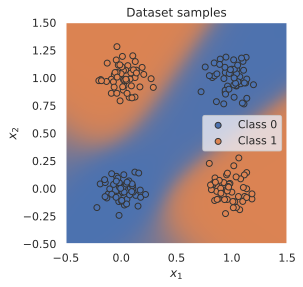

In [56]:
@torch.no_grad() # Decorator, same effect as "with torch.no_grad(): ..." over the whole function.
def visualize_classification(model, data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    fig = plt.figure(figsize=(4,4), dpi=500)
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

    # Let's make use of a lot of operations we have learned above
    model.to(device)
    c0 = torch.Tensor(to_rgba("C0")).to(device)
    c1 = torch.Tensor(to_rgba("C1")).to(device)
    x1 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    x2 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    xx1, xx2 = torch.meshgrid(x1, x2, indexing='ij')  # Meshgrid function as in numpy
    model_inputs = torch.stack([xx1, xx2], dim=-1)
    preds = model(model_inputs)
    preds = torch.sigmoid(preds)
    output_image = (1 - preds) * c0[None,None] + preds * c1[None,None]  # Specifying "None" in a dimension creates a new one
    output_image = output_image.cpu().numpy()  # Convert to numpy array. This only works for tensors on CPU, hence first push to CPU
    plt.imshow(output_image, origin='lower', extent=(-0.5, 1.5, -0.5, 1.5))
    plt.grid(False)
    return fig

_ = visualize_classification(model, dataset.data, dataset.label)
plt.show()

The decision boundaries might not look exactly as in the figure in the preamble of this section which can be caused by running it on CPU or a different GPU architecture. Nevertheless, the result on the accuracy metric should be the approximately the same.

<span style="color: gold; font-size: 30px;">Part 2: Questions</span>

### ❓ Question 1:

What is the difference between a Dataset and a DataLoader in PyTorch? Explain the role each one plays in the training pipeline.

A Dataset defines what the data is and how to retrieve a single sample and its label using len and getitem. This is where you typically load raw inputs, apply preprocessing, and convert them to tensors. A DataLoader wraps a Dataset and controls how data is fed to the model by forming mini-batches, shuffling data each epoch if needed, loading data in parallel with multiple workers, and using a collate function to combine samples into a batch, which is especially important for variable-length inputs like text.

### ❓ Question 2:

Why do we call optimizer.zero_grad() before performing loss.backward()? What would happen if we skipped this step?

PyTorch accumulates gradients by default, meaning each call to backward adds new gradients to the existing ones stored in parameter grad fields. Calling optimizer.zero_grad clears the previous gradients so the current batch computes a fresh gradient. If you skip this step, gradients from multiple batches will pile up, leading to incorrect gradient values and unstable or misleading training behavior.

### ❓ Question 3:

What is the difference between model.train() and model.eval()? Why is it important to switch between these two modes during training and evaluation?

model.train sets the model to training mode, enabling training-specific behaviors such as Dropout being active and BatchNorm using and updating batch statistics. model.eval sets the model to evaluation mode, disabling Dropout and making BatchNorm use stored running statistics without updating them. Switching matters because evaluating in train mode can make predictions noisy and accuracy unreliable, and training in eval mode prevents proper regularization and normalization, harming learning.

### <span style="color: Blue; font-size: 50px;">CNN</span>


In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/Ai/snappfood/train.csv", sep="\t", encoding="utf-8")
dev_df   = pd.read_csv("/content/drive/MyDrive/Ai/snappfood/dev.csv",   sep="\t", encoding="utf-8")
test_df  = pd.read_csv("/content/drive/MyDrive/Ai/snappfood/test.csv",  sep="\t", encoding="utf-8")

for df in (train_df, dev_df, test_df):
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

print(train_df.columns)
print(train_df.head(2))

Index(['comment', 'label', 'label_id'], dtype='object')
                                             comment  label  label_id
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح    SAD         1
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...  HAPPY         0


In [59]:
import torch
from torch.utils.data import Dataset

class SnappFoodDataset(Dataset):
    def __init__(self, df, text_col="comment", label_col="label_id", text_transform=None):
        self.texts = df[text_col].astype(str).tolist()

        self.has_label = (label_col in df.columns)
        self.labels = df[label_col].astype(int).tolist() if self.has_label else None

        self.text_transform = text_transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.text_transform is not None:
            text = self.text_transform(text)

        if self.has_label:
            y = torch.tensor(self.labels[idx], dtype=torch.long)
            return text, y
        else:
            return text


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


  یک کلاس SnappFoodDataset از Dataset ساختم تا دسترسی به داده‌ها استاندارد و تمیز باشد  
داخل کلاس متن‌ها را در لیست نگه داشتم و اگر ستون label_id موجود بود، برچسب‌ها را هم ذخیره کردم  
در __getitem__ اگر transform داده شده باشد روی متن اعمال می‌شود و خروجی به‌صورت (ورودی، برچسب) برمی‌گردد

In [60]:
from torch.utils.data import DataLoader

train_ds = SnappFoodDataset(train_df)
dev_ds   = SnappFoodDataset(dev_df)
test_ds  = SnappFoodDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

batch = next(iter(train_loader))
print(type(batch), len(batch))
print(batch[0][0], batch[1][0])

<class 'list'> 2
وسطش نپخته بود اصلا خوب نبود خام بود tensor(1)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

  از همین Dataset برای ساخت train_ds/dev_ds/test_ds استفاده کردم تا داده‌ها آماده ورود به DataLoader شوند  
سه DataLoader با batch_size مناسب ساخته شد، train با shuffle=True برای یادگیری بهتر و dev/test بدون شافل برای حفظ ترتیب  
در انتها یک batch نمونه گرفتم و نوع خروجی و یک نمونه متن/لیبل را چاپ کردم تا ساختار درست باشد  

In [61]:
import re

EN2FA_DIGITS = str.maketrans("0123456789", "۰۱۲۳۴۵۶۷۸۹")

URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)")
MENTION_PATTERN = re.compile(r"@\w+")

MULTI_SPACE_PATTERN = re.compile(r"\s+")
ALLOWED_PATTERN = re.compile(r"[^آ-ی۰-۹0-9\s\.\,\!\?\؟\،\؛\:\(\)\-\_\u200c]")


def preprocess_text(text: str, stopwords: set):
    if not isinstance(text, str):
        text = str(text)
    text = text.replace("ي", "ی").replace("ك", "ک")
    text = text.translate(EN2FA_DIGITS)
    text = URL_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = ALLOWED_PATTERN.sub(" ", text)
    text = MULTI_SPACE_PATTERN.sub(" ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords]
    return " ".join(tokens)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

 تابع preprocess_text را برای پاکسازی متن مطابق نیاز پروژه پیاده‌سازی کردم  
نرمال‌سازی ی/ک، تبدیل اعداد انگلیسی به فارسی، حذف لینک و منشن، حذف کاراکترهای نامعتبر و جمع کردن فاصله‌های اضافی انجام می‌شود  
در انتها متن توکنایز می‌شود و stopwordها حذف می‌شوند تا ورودی مدل نویز کمتر و معنای بیشتری داشته باشد

In [62]:
import os

def load_stopwords(path):
    if not os.path.exists(path):
        directory = os.path.dirname(path)
        print(f"Warning: Stopwords file not found at '{path}'.")
        print(f"Please ensure the file 'stopwords-fa.txt' is correctly placed in '{directory}'.")
        if os.path.exists(directory):
            print(f"Contents of directory '{directory}': {os.listdir(directory)}")
        else:
            print(f"Directory '{directory}' does not exist. Please check your Google Drive mount and path.")
        print("Proceeding with an empty set of stopwords. This may affect preprocessing results.")
        return set()
    with open(path, "r", encoding="utf-8") as f:
        return set(w.strip() for w in f if w.strip())

stopwords_file_path = "/content/drive/MyDrive/Ai/stopwords-fa.txt"
stopwords = load_stopwords(stopwords_file_path)

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">



یک تابع load_stopwords نوشتم که فایل stopwords را از مسیر مشخص بخواند و set بسازد  
اگر فایل پیدا نشود، هشدار و مسیر/محتوای پوشه را چاپ می‌کند تا مشکل مسیر Drive سریع مشخص شود  
در نهایت stopwords از فایل stopwords-fa.txt روی Drive لود شد تا در پیش‌پردازش استفاده شود

In [63]:
train_ds = SnappFoodDataset(
    train_df,
    text_transform=lambda t: preprocess_text(t, stopwords)
)
dev_ds = SnappFoodDataset(
    dev_df,
    text_transform=lambda t: preprocess_text(t, stopwords)
)
test_ds = SnappFoodDataset(
    test_df,
    text_transform=lambda t: preprocess_text(t, stopwords)
)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

 دیتاست‌ها را دوباره ساختم اما این بار text_transform را روی preprocess_text تنظیم کردم  
به این ترتیب هر بار DataLoader نمونه می‌خواهد، متن همان لحظه پیش‌پردازش می‌شود و خروجی تمیز برمی‌گردد  
این کار باعث می‌شود کل pipeline یکپارچه باشد و نیاز به ساخت ستون جدید در دیتافریم نباشد

In [64]:
raw = train_df.loc[0, "comment"]
clean = preprocess_text(raw, stopwords)
print("RAW:", raw)
print("CLEAN:", clean)


RAW: واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
CLEAN: حیف وقت بنویسم سرویس دهیتون افتضاح


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


  برای اطمینان، یک کامنت خام از train را گرفتم و نسخه‌ی پیش‌پردازش‌شده‌اش را تولید کردم  
RAW و CLEAN را چاپ کردم تا اثر نرمال‌سازی، حذف لینک/منشن، حذف نویسه‌های اضافی و stopwordها را ببینم  
این تست ساده کمک می‌کند اگر خروجی خالی یا خراب شد، همان‌جا مشکل stopwords یا regexها مشخص شود

In [65]:

import os, shutil, fasttext

FT_PATH = "/content/drive/MyDrive/Ai/cc.fa.300.bin"
FT_LOCAL = "/content/cc.fa.300.bin"

if not os.path.exists(FT_LOCAL):
    shutil.copy(FT_PATH, FT_LOCAL)

ft = fasttext.load_model(FT_LOCAL)
EMB_DIM = ft.get_dimension()

MAX_LEN = 50

def text_to_embedding_tensor(text: str, stopwords: set, max_len: int = MAX_LEN):
    text = preprocess_text(text, stopwords)
    tokens = text.split()[:max_len]
    mat = np.zeros((EMB_DIM, max_len), dtype=np.float32)
    for i, tok in enumerate(tokens):
        mat[:, i] = ft.get_word_vector(tok)
    return torch.tensor(mat, dtype=torch.float32)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

  متنِ پیش‌پردازش‌شده را به ورودی عددیِ ثابت‌طول برای شبکه CNN تبدیل کردم. ابتدا مدل fastText را از Drive به مسیر /content کپی کردم تا بارگذاری و دسترسی به فایل ۴ گیگی سریع‌تر باشد و بعد با fasttext.load_model مدل را لود کردم و EMB_DIM (مثلاً 300) را از آن گرفتم. سپس یک MAX_LEN تعیین کردم تا طول همه جمله‌ها ثابت شود و بتوانیم batch بسازیم و Conv1D بدون مشکل روی ورودی اجرا شود.

در تابع text_to_embedding_tensor متن را با preprocess_text تمیز کردم و آن را به لیست کلمات تبدیل کردم. اینجا “concatenation” یعنی بردارِ هر کلمه را پشت سر هم کنار هم قرار می‌دهیم تا یک نمایش واحد برای جمله بسازیم. پیاده‌سازی من به این شکل است که یک ماتریس با ابعاد (EMB_DIM, MAX_LEN) می‌سازم که هر ستون آن embedding یک کلمه است؛ یعنی ستون 0 بردار کلمه اول، ستون 1 بردار کلمه دوم و الی آخر. اگر جمله کوتاه باشد ستون‌های باقی‌مانده صفر می‌مانند (padding) و اگر جمله بلند باشد فقط MAX_LEN کلمه اول نگه داشته می‌شود (truncate). نتیجه این می‌شود که همه جمله‌ها دقیقاً یک شکل ثابت دارند و به صورت مستقیم قابل ورود به CNN هستند.

این نوع concatenation با معماری Conv1D کاملاً سازگار است چون در PyTorch ورودی Conv1D باید شکل (batch, channels, seq_len) داشته باشد. ما channels را برابر EMB_DIM گذاشتیم و seq_len را برابر MAX_LEN، پس کانولوشن روی محور طول جمله حرکت می‌کند و الگوهای محلی چندکلمه‌ای مثل n-gram را یاد می‌گیرد. بنابراین عملاً پل بین متن خام و داده عددی استاندارد برای CNN است و با padding/truncate مشکل طول‌های مختلف جمله را حل می‌کند.

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


In [66]:
from torch.utils.data import DataLoader

train_ds = SnappFoodDataset(train_df, text_transform=lambda t: text_to_embedding_tensor(t, stopwords))
dev_ds   = SnappFoodDataset(dev_df,   text_transform=lambda t: text_to_embedding_tensor(t, stopwords))
test_ds  = SnappFoodDataset(test_df,  text_transform=lambda t: text_to_embedding_tensor(t, stopwords))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

x, y = next(iter(train_loader))
print(x.shape, y.shape, x.dtype, y.dtype)


torch.Size([64, 300, 50]) torch.Size([64]) torch.float32 torch.int64


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


  این بار Datasetها را طوری ساختم که خروجی‌شان تنسور embedding باشد نه متن خام  
DataLoaderها ساخته شدند تا batchهایی با شکل ثابت به مدل CNN داده شود و train/dev/test مثل قبل مدیریت شوند  
یک batch گرفتم و shape و dtype را چاپ کردم تا مطمئن شوم ورودی مدل (batch, EMB_DIM, MAX_LEN) و برچسب‌ها long هستند  

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


In [67]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TextCNN(nn.Module):
    def __init__(self, input_dimension, max_len, dropout_p=0.3):
        super().__init__()
        self.conv = nn.Conv1d(input_dimension, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.drop = nn.Dropout(dropout_p)
        self.relu = nn.ReLU()
        pooled_len = max_len // 2
        self.fc = nn.Linear(128 * pooled_len, 2)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x

model = TextCNN(input_dimension=EMB_DIM, max_len=MAX_LEN, dropout_p=0.3).to(device)
print(model)


TextCNN(
  (conv): Conv1d(300, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
  (fc): Linear(in_features=3200, out_features=2, bias=True)
)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

  این  تعریف مدل CNN متنی است که طبق معماری پیشنهادی تمرین ساخته شد. ورودی مدل یک تنسور با شکل (batch, EMB_DIM, MAX_LEN) است که از fastText ساخته‌ایم، بنابراین input_dimension همان EMB_DIM است. در لایه Conv1D با 128 فیلتر و kernel_size=3 روی محور طول جمله حرکت می‌کنیم تا الگوهای محلی سه‌کلمه‌ای (شبیه 3-gram) را استخراج کنیم و با padding=1 طول توالی بعد از کانولوشن حفظ می‌شود. بعد از آن ReLU گذاشته می‌شود تا مدل غیرخطی شود و بتواند روابط پیچیده‌تری بین کلمات را یاد بگیرد. سپس MaxPool1d با kernel_size=2 طول توالی را نصف می‌کند، هم محاسبات را کمتر می‌کند و هم ویژگی‌های قوی‌تر را نگه می‌دارد. برای جلوگیری از Dropout، overfitting بعد از pooling قرار داده شد تا در زمان آموزش بخشی از ویژگی‌ها تصادفی صفر شوند و مدل به چند ویژگی خاص وابسته نشود. در انتها خروجی کانولوشن و pooling به شکل (batch, 128, MAX_LEN/2) است که flatten می‌شود و وارد Linear می‌گردد تا دو خروجی برای کلاس‌های HAPPY و SAD تولید کند، و مدل روی device منتقل می‌شود تا روی GPU یا CPU قابل اجرا باشد.

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


In [68]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    dv_loss, dv_acc = run_epoch(dev_loader, train=False)
    print(epoch, tr_loss, tr_acc, dv_loss, dv_acc)


1 0.4488666250970629 0.7893650793650794 0.4151888432010772 0.8088888888888889
2 0.3982171867638038 0.8212169312169312 0.4047336775159079 0.812063492063492
3 0.3778477466526906 0.8298765432098766 0.39832536137293256 0.8158730158730159
4 0.3603116390103806 0.839047619047619 0.4032858822837708 0.8161904761904762
5 0.34067999554058864 0.8491181657848325 0.4087748231585064 0.8111111111111111
6 0.3245543629509221 0.8573015873015873 0.40735620843039616 0.813015873015873
7 0.307846660040043 0.8652204585537919 0.42173961459644255 0.8147619047619048
8 0.2924536348860941 0.873668430335097 0.42765487748479086 0.8093650793650794
9 0.2784496069143689 0.8808112874779541 0.43181300305184867 0.8095238095238095
10 0.2652543748308111 0.8872663139329806 0.4417243827903081 0.8117460317460318


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

  تابع هزینه CrossEntropyLoss و بهینه‌ساز Adam تعریف شد تا مدل برای طبقه‌بندی دوکلاسه آموزش ببیند  
تابع run_epoch نوشتم که حالت train/eval را مدیریت می‌کند، در train گرادیان‌ها را صفر می‌کند، backward می‌زند و پارامترها را آپدیت می‌کند  
مدل حداقل 10 epoch آموزش داده شد و در هر epoch loss و accuracy برای train و dev چاپ شد تا روند یادگیری قابل مشاهده باشد  

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


In [69]:
ts_loss, ts_acc = run_epoch(test_loader, train=False)
print("test_loss", ts_loss)
print("test_acc", ts_acc)


test_loss 0.4323764718260084
test_acc 0.8124285714285714


 <div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

 بعد از آموزش، مدل را روی test با train=False ارزیابی کردم تا dropout خاموش باشد و ارزیابی واقعی‌تر انجام شود  
میانگین test_loss و test_acc محاسبه و چاپ شد تا عملکرد نهایی گزارش شود  
این مرحله معیار اصلی صحت مدل روی داده‌ی دیده‌نشده را نشان می‌دهد  

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


In [70]:
import pandas as pd
import torch

model.eval()
preds = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        x = x.to(device)
        logits = model(x)
        preds.extend(logits.argmax(dim=1).cpu().tolist())

out_df = test_df.copy()
out_df["predicted"] = preds

out_df.to_csv("test_with_predicted.csv", index=False, encoding="utf-8-sig")
out_df.to_excel("test_with_predicted.xlsx", index=False)


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">


 مدل را eval کردم و داخل torch.no_grad روی کل test_loader پیش‌بینی گرفتم تا محاسبه گرادیان انجام نشود  
با argmax روی logits برای هر نمونه یک کلاس انتخاب شد و یک ستون جدید predicted به test_df اضافه شد  
خروجی نهایی هم به صورت CSV با utf-8-sig و هم Excel ذخیره شد تا آماده تحویل و بررسی در اکسل باشد  

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">
